In [2]:
# ============================================================
# CELL 1 — Import Libraries + Load master_features.csv
# Phase 4: Modeling | Credit Risk Scorecard Project
# ============================================================

# --- Core ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- Imbalance Handling ---
from imblearn.over_sampling import SMOTE

# --- Models ---
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# --- Evaluation ---
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    
)

# --- Explainability ---
import shap

# --- Model Saving ---
import joblib

# --- Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42

print("✅ All libraries imported successfully")

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv('../Data/master_features.csv')

print(f"\n📦 master_features.csv loaded")
print(f"   Shape     : {df.shape}")
print(f"   Target dist:\n{df['TARGET'].value_counts(normalize=True).round(4)}")
print(f"\n📋 Columns ({df.shape[1]}):")
print(df.columns.tolist())
print(f"\n🔍 Data types:")
print(df.dtypes.value_counts())
print(f"\n🚨 Missing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   None — all clean ✅")

✅ All libraries imported successfully

📦 master_features.csv loaded
   Shape     : (307511, 26)
   Target dist:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

📋 Columns (26):
['EXT_SOURCE_MIN', 'CREDIT_TERM', 'CREDIT_INCOME_RATIO', 'EXT_SOURCE_1', 'ANNUITY_INCOME_RATIO', 'BUREAU_TOTAL_DEBT', 'AMT_ANNUITY', 'EXT_SOURCE_2', 'AGE_EMPLOYMENT_RATIO', 'AGE_YEARS', 'AMT_CREDIT', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'BUREAU_AVG_OVERDUE', 'BUREAU_ACTIVE_RATIO', 'PREV_APPROVAL_RATE', 'BUREAU_MAX_OVERDUE_DAYS', 'NAME_INCOME_TYPE', 'PREV_REFUSED_COUNT', 'NAME_EDUCATION_TYPE', 'REGION_RATING_CLIENT', 'CODE_GENDER', 'DOCUMENTS_SUBMITTED', 'NAME_FAMILY_STATUS', 'TARGET', 'SK_ID_CURR']

🔍 Data types:
float64    18
object      4
int64       4
Name: count, dtype: int64

🚨 Missing values:
CREDIT_TERM                12
ANNUITY_INCOME_RATIO       12
BUREAU_TOTAL_DEBT       44020
AMT_ANNUITY                12
AGE_EMPLOYMENT_RATIO    55374
dtype: int64


In [4]:
# Load master features
df = pd.read_csv('../Data/master_features.csv')

print(f"Shape: {df.shape}")
print(f"Missing values before fix: {df.isnull().sum().sum()}")

# Fix missing values
df['AGE_EMPLOYMENT_RATIO'] = df['AGE_EMPLOYMENT_RATIO'].fillna(
    df['AGE_EMPLOYMENT_RATIO'].median()
)

df['BUREAU_TOTAL_DEBT'] = df['BUREAU_TOTAL_DEBT'].fillna(0)

# Fix any other remaining columns
for col in df.columns:
    if col in ['TARGET', 'SK_ID_CURR']:
        continue
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# Resave clean version
df.to_csv('../Data/master_features.csv', index=False)

print(f"Missing values after fix : {df.isnull().sum().sum()}")
print(f"master_features.csv resaved ✓")
print(f"Final shape: {df.shape}")

Shape: (307511, 26)
Missing values before fix: 0
Missing values after fix : 0
master_features.csv resaved ✓
Final shape: (307511, 26)


In [5]:
# ============================================================
# CELL 2 — Encode Categorical Columns with LabelEncoder
# ============================================================

# Identify categorical columns (exclude ID and target)
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"📋 Categorical columns found: {len(cat_cols)}")
print(cat_cols)

# Encode each categorical column
label_encoders = {}  # save encoders in case needed later

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"   ✅ {col} — {le.classes_} → {list(range(len(le.classes_)))}")

print(f"\n✅ All categorical columns encoded")
print(f"   Shape unchanged: {df.shape}")
print(f"\n🔍 dtypes after encoding:")
print(df.dtypes.value_counts())

📋 Categorical columns found: 4
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'NAME_FAMILY_STATUS']
   ✅ NAME_INCOME_TYPE — ['Businessman' 'Commercial associate' 'Maternity leave' 'Pensioner'
 'State servant' 'Student' 'Unemployed' 'Working'] → [0, 1, 2, 3, 4, 5, 6, 7]
   ✅ NAME_EDUCATION_TYPE — ['Academic degree' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Secondary / secondary special'] → [0, 1, 2, 3, 4]
   ✅ CODE_GENDER — ['F' 'M' 'XNA'] → [0, 1, 2]
   ✅ NAME_FAMILY_STATUS — ['Civil marriage' 'Married' 'Separated' 'Single / not married' 'Unknown'
 'Widow'] → [0, 1, 2, 3, 4, 5]

✅ All categorical columns encoded
   Shape unchanged: (307511, 26)

🔍 dtypes after encoding:
float64    18
int64       8
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 3 — Train/Test Split (Stratified 80/20)
# ============================================================

# Separate features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\n Target distribution (full data):")
print(y.value_counts())
print(y.value_counts(normalize=True).round(4))

# Stratified split — preserves 8% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\n Split complete")
print(f"   X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

print(f"\n Target distribution in TRAIN set:")
print(y_train.value_counts(normalize=True).round(4))

print(f"\n Target distribution in TEST set:")
print(y_test.value_counts(normalize=True).round(4))

Features shape : (307511, 24)
Target shape   : (307511,)

 Target distribution (full data):
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

 Split complete
   X_train : (246008, 24)  |  y_train : (246008,)
   X_test  : (61503, 24)   |  y_test  : (61503,)

 Target distribution in TRAIN set:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

 Target distribution in TEST set:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


In [7]:
# ============================================================
# CELL 4 — Apply SMOTE on Training Data Only
# SMOTE = Synthetic Minority Oversampling Technique
# Creates synthetic defaulter samples to balance the dataset
# IMPORTANT: Apply SMOTE only on training data, never on test data
# ============================================================

print(f"  Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True).round(4))

# Apply SMOTE — sampling_strategy=0.3 means:
# minorities (defaulters) will become 30% of majority class size
# NOT 50/50 — keeps it realistic while giving model enough signal
smote = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n SMOTE applied successfully")
print(f"\n Class distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(pd.Series(y_train_sm).value_counts(normalize=True).round(4))

print(f"\n X_train_sm shape : {X_train_sm.shape}")
print(f" y_train_sm shape : {y_train_sm.shape}")
print(f"\n X_test untouched : {X_test.shape}  ← real-world distribution preserved")

  Class distribution BEFORE SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64

 SMOTE applied successfully

 Class distribution AFTER SMOTE:
TARGET
0    226148
1     67844
Name: count, dtype: int64
TARGET
0   0.7692
1   0.2308
Name: proportion, dtype: float64

 X_train_sm shape : (293992, 24)
 y_train_sm shape : (293992,)

 X_test untouched : (61503, 24)  ← real-world distribution preserved


In [8]:
# Scale Features 
# ============================================================
# CELL 5 — StandardScaler (Fit on SMOTE train, Transform test)
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)       # transform only — no fit

print(f" Scaling complete")
print(f"   X_train_scaled shape : {X_train_scaled.shape}")
print(f"   X_test_scaled shape  : {X_test_scaled.shape}")

# Sanity check — mean should be ~0, std ~1 for train
print(f"\n📊 Sanity check on X_train_scaled:")
print(f"   Mean (first 5 cols) : {X_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"   Std  (first 5 cols) : {X_train_scaled[:, :5].std(axis=0).round(4)}")

print(f"\n Scaler fitted on training data only — no data leakage ✅")
print(f"   Note: X_test_scaled uses train statistics (mean/std) for transform")


 Scaling complete
   X_train_scaled shape : (293992, 24)
   X_test_scaled shape  : (61503, 24)

📊 Sanity check on X_train_scaled:
   Mean (first 5 cols) : [ 0.  0.  0. -0.  0.]
   Std  (first 5 cols) : [1. 1. 1. 1. 1.]

 Scaler fitted on training data only — no data leakage ✅
   Note: X_test_scaled uses train statistics (mean/std) for transform


In [9]:
from scipy.stats import ks_2samp

In [10]:
# ============================================================
# CELL 6 — Train Logistic Regression
# ============================================================
from datetime import datetime

print("⏳ Training Logistic Regression...")
start = datetime.now()

lr = LogisticRegression(
    class_weight='balanced',   # penalizes misclassifying minority more
    max_iter=1000,             # enough iterations to converge
    solver='lbfgs',            # best solver for medium-sized binary problems
    C=0.1,                     # regularization — prevents overfitting
    random_state=RANDOM_STATE
)

lr.fit(X_train_scaled, y_train_sm)

end = datetime.now()
print(f"✅ Training complete in {(end - start).seconds}s")

# --- Predictions ---
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]  # probability of default
lr_preds = lr.predict(X_test_scaled)

# --- Metrics ---
lr_auc  = roc_auc_score(y_test, lr_probs)
lr_gini = 2 * lr_auc - 1

# KS Statistic
defaulters     = lr_probs[y_test == 1]
non_defaulters = lr_probs[y_test == 0]
lr_ks, _       = ks_2samp(defaulters, non_defaulters)

print(f"\n📊 Logistic Regression — Test Set Results")
print(f"   AUC-ROC : {lr_auc:.4f}")
print(f"   Gini    : {lr_gini:.4f}")
print(f"   KS Stat : {lr_ks:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, lr_preds, target_names=['Repaid', 'Defaulted']))

⏳ Training Logistic Regression...
✅ Training complete in 5s

📊 Logistic Regression — Test Set Results
   AUC-ROC : 0.7065
   Gini    : 0.4130
   KS Stat : 0.3057

📋 Classification Report:
              precision    recall  f1-score   support

      Repaid       0.95      0.70      0.81     56538
   Defaulted       0.15      0.60      0.24      4965

    accuracy                           0.69     61503
   macro avg       0.55      0.65      0.52     61503
weighted avg       0.89      0.69      0.76     61503



In [11]:
# ============================================================
# CELL 7 — Train XGBoost
# ============================================================

# scale_pos_weight balances classes for XGBoost
# = count of negatives / count of positives in ORIGINAL train set
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"⚖️  scale_pos_weight : {scale_pos_weight:.2f}")

print(" Training XGBoost...")
start = datetime.now()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# XGBoost does NOT need scaled data — use raw SMOTE train
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100           # prints AUC every 100 rounds
)

end = datetime.now()
print(f"\n Training complete in {(end - start).seconds}s")

# --- Predictions ---
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

# --- Metrics ---
xgb_auc  = roc_auc_score(y_test, xgb_probs)
xgb_gini = 2 * xgb_auc - 1

defaulters_xgb     = xgb_probs[y_test == 1]
non_defaulters_xgb = xgb_probs[y_test == 0]
xgb_ks, _          = ks_2samp(defaulters_xgb, non_defaulters_xgb)

print(f"\n📊 XGBoost — Test Set Results")
print(f"   AUC-ROC : {xgb_auc:.4f}")
print(f"   Gini    : {xgb_gini:.4f}")
print(f"   KS Stat : {xgb_ks:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Repaid', 'Defaulted']))

⚖️  scale_pos_weight : 11.39
 Training XGBoost...
[0]	validation_0-auc:0.65689
[100]	validation_0-auc:0.72671
[200]	validation_0-auc:0.73432
[299]	validation_0-auc:0.73911

 Training complete in 27s

📊 XGBoost — Test Set Results
   AUC-ROC : 0.7391
   Gini    : 0.4782
   KS Stat : 0.3524

📋 Classification Report:
              precision    recall  f1-score   support

      Repaid       0.97      0.58      0.72     56538
   Defaulted       0.14      0.76      0.23      4965

    accuracy                           0.59     61503
   macro avg       0.55      0.67      0.48     61503
weighted avg       0.90      0.59      0.68     61503



In [12]:
# ============================================================
# CELL 8 — Compare Both Models
# ============================================================

print("=" * 50)
print("       MODEL COMPARISON — TEST SET RESULTS")
print("=" * 50)

results = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Gini Coefficient', 'KS Statistic'],
    'Logistic Regression': [lr_auc, lr_gini, lr_ks],
    'XGBoost':             [xgb_auc, xgb_gini, xgb_ks]
})

results['Better Model'] = results.apply(
    lambda row: 'XGBoost' if row['XGBoost'] > row['Logistic Regression']
    else 'Logistic Regression', axis=1
)

# Format for display
results['Logistic Regression'] = results['Logistic Regression'].round(4)
results['XGBoost']             = results['XGBoost'].round(4)

print(results.to_string(index=False))

print("\n" + "=" * 50)
print(f"  LR  → AUC: {lr_auc:.4f} | Gini: {lr_gini:.4f} | KS: {lr_ks:.4f}")
print(f"  XGB → AUC: {xgb_auc:.4f} | Gini: {xgb_gini:.4f} | KS: {xgb_ks:.4f}")
print("=" * 50)

# Improvement delta
print(f"\n📈 XGBoost improvement over LR:")
print(f"   AUC  : +{(xgb_auc  - lr_auc):.4f}")
print(f"   Gini : +{(xgb_gini - lr_gini):.4f}")
print(f"   KS   : +{(xgb_ks   - lr_ks):.4f}")

print(f"\n✅ XGBoost selected as performance model")
print(f"✅ Logistic Regression retained for scorecard (Phase 5)")

       MODEL COMPARISON — TEST SET RESULTS
          Metric  Logistic Regression  XGBoost Better Model
         AUC-ROC               0.7065   0.7391      XGBoost
Gini Coefficient               0.4130   0.4782      XGBoost
    KS Statistic               0.3057   0.3524      XGBoost

  LR  → AUC: 0.7065 | Gini: 0.4130 | KS: 0.3057
  XGB → AUC: 0.7391 | Gini: 0.4782 | KS: 0.3524

📈 XGBoost improvement over LR:
   AUC  : +0.0326
   Gini : +0.0652
   KS   : +0.0467

✅ XGBoost selected as performance model
✅ Logistic Regression retained for scorecard (Phase 5)


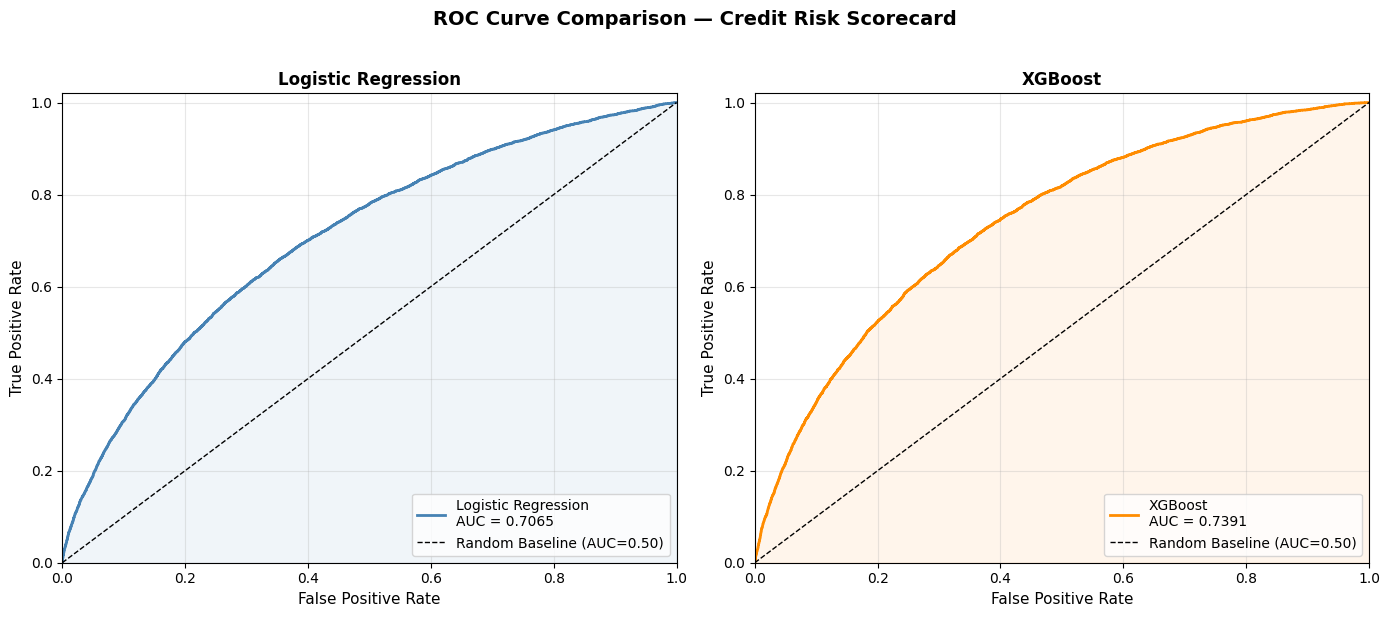

✅ ROC curve saved → models/roc_curve_comparison.png


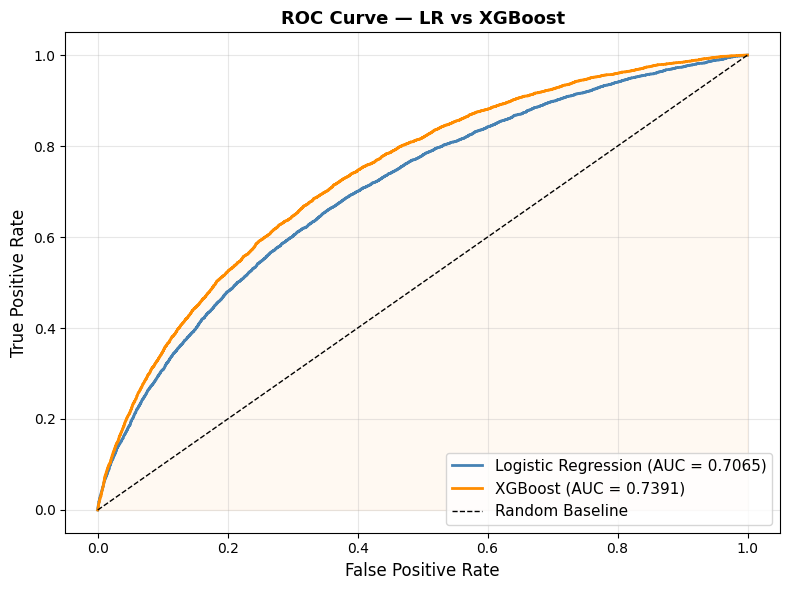

✅ Combined ROC curve saved → models/roc_curve_combined.png


In [14]:
# ============================================================
# CELL 9 — ROC Curve Comparison Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curve Comparison — Credit Risk Scorecard', 
             fontsize=14, fontweight='bold', y=1.02)

models = [
    ('Logistic Regression', lr_probs,  lr_auc,  'steelblue',  axes[0]),
    ('XGBoost',             xgb_probs, xgb_auc, 'darkorange',  axes[1])
]

for name, probs, auc, color, ax in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    # ROC curve
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name}\nAUC = {auc:.4f}')
    
    # Random baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline (AUC=0.50)')
    
    # Shading under curve
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    
    # Labels
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curve saved → models/roc_curve_comparison.png")

# --- Combined plot on single axes for README ---
fig2, ax2 = plt.subplots(figsize=(8, 6))

for name, probs, auc, color in [
    ('Logistic Regression', lr_probs,  lr_auc,  'steelblue'),
    ('XGBoost',             xgb_probs, xgb_auc, 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax2.fill_between(*roc_curve(y_test, xgb_probs)[:2], alpha=0.05, color='darkorange')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve — LR vs XGBoost', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/roc_curve_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Combined ROC curve saved → models/roc_curve_combined.png")

⏳ Computing SHAP values (may take 30-60s)...
✅ SHAP values computed
   shap_values shape : (61503, 24)

📊 Generating Beeswarm Summary Plot...


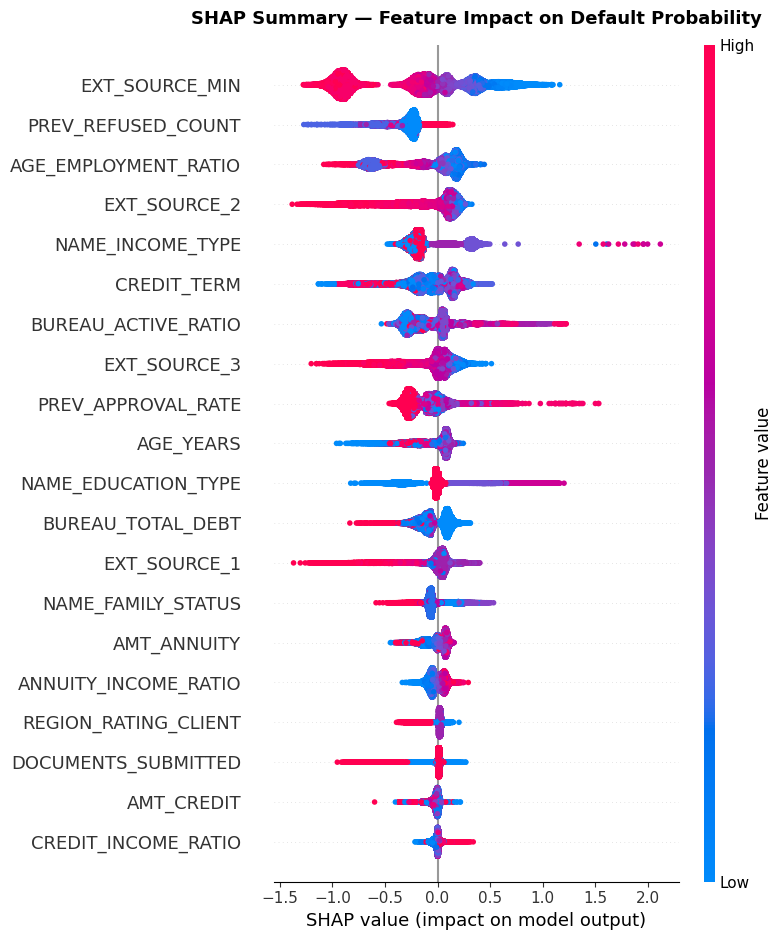

✅ Saved → models/shap_beeswarm.png

📊 Generating Bar Importance Plot...


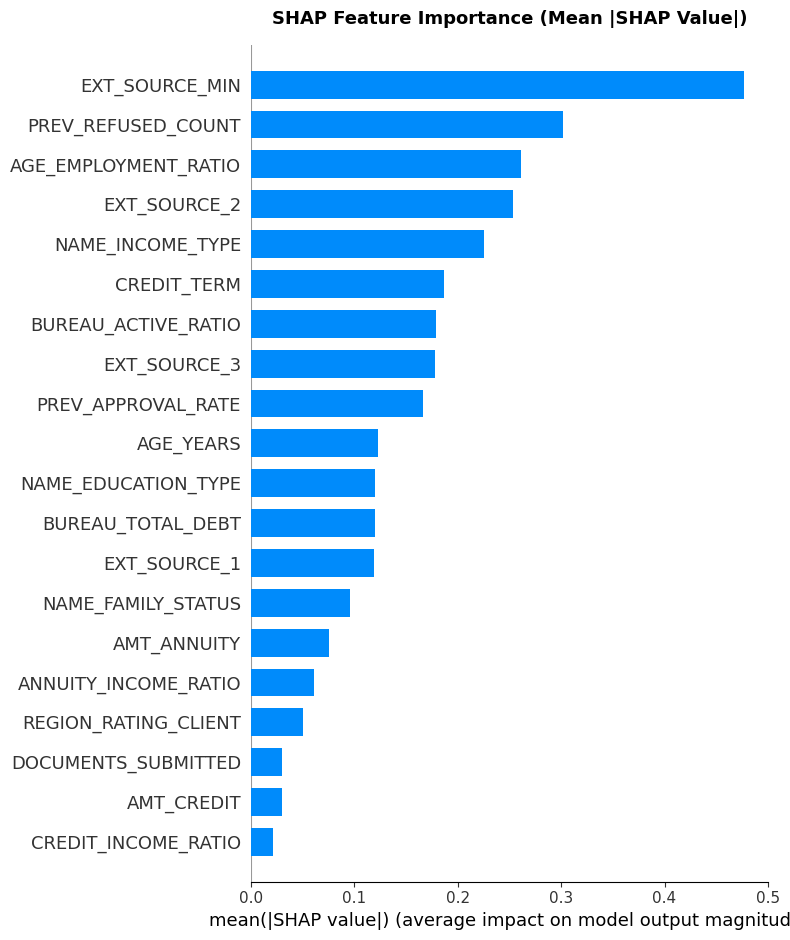

✅ Saved → models/shap_importance_bar.png

🏆 Top 10 Most Influential Features (XGBoost):
             Feature  Mean |SHAP|
      EXT_SOURCE_MIN       0.4764
  PREV_REFUSED_COUNT       0.3021
AGE_EMPLOYMENT_RATIO       0.2608
        EXT_SOURCE_2       0.2532
    NAME_INCOME_TYPE       0.2253
         CREDIT_TERM       0.1865
 BUREAU_ACTIVE_RATIO       0.1792
        EXT_SOURCE_3       0.1782
  PREV_APPROVAL_RATE       0.1664
           AGE_YEARS       0.1229


In [15]:
# ============================================================
# CELL 10 — SHAP Values for XGBoost Explainability
# ============================================================

print("⏳ Computing SHAP values (may take 30-60s)...")

# TreeExplainer is optimised for tree-based models like XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed")
print(f"   shap_values shape : {shap_values.shape}")

# --- Feature names for readable plots ---
feature_names = X.columns.tolist()

# ── Plot 1: Beeswarm Summary Plot ────────────────────────────
print("\n📊 Generating Beeswarm Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary — Feature Impact on Default Probability',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../models/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → models/shap_beeswarm.png")

# ── Plot 2: Bar Plot (Mean Absolute SHAP) ────────────────────
print("\n📊 Generating Bar Importance Plot...")
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../models/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → models/shap_importance_bar.png")

# ── Top 5 Features Summary ────────────────────────────────────
mean_shap = pd.DataFrame({
    'Feature'         : feature_names,
    'Mean |SHAP|'     : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n🏆 Top 10 Most Influential Features (XGBoost):")
print(mean_shap.head(10).to_string(index=False))

In [16]:
# ============================================================
# CELL 11 — Save Models with Joblib
# ============================================================
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# --- Save Logistic Regression ---
joblib.dump(lr, '../models/logistic_regression.pkl')
print("✅ Logistic Regression saved → models/logistic_regression.pkl")

# --- Save Scaler ---
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler saved             → models/scaler.pkl")

# --- Save XGBoost ---
xgb_model.save_model('../models/xgboost_model.json')
print("✅ XGBoost saved            → models/xgboost_model.json")

# --- Save feature names (critical for Streamlit Phase 6) ---
import json
feature_names = X.columns.tolist()
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("✅ Feature names saved      → models/feature_names.json")

# --- Save label encoders ---
joblib.dump(label_encoders, '../models/label_encoders.pkl')
print("✅ Label encoders saved     → models/label_encoders.pkl")

# --- Verification ---
print("\n📁 Files in models/ folder:")
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"   {f:<35} {size:.1f} KB")

# --- Final Phase 4 Summary ---
print("\n" + "=" * 55)
print("         PHASE 4 COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"\n  Logistic Regression")
print(f"    AUC-ROC : {lr_auc:.4f}")
print(f"    Gini    : {lr_gini:.4f}")
print(f"    KS Stat : {lr_ks:.4f}")
print(f"\n  XGBoost")
print(f"    AUC-ROC : {xgb_auc:.4f}")
print(f"    Gini    : {xgb_gini:.4f}")
print(f"    KS Stat : {xgb_ks:.4f}")
print(f"\n  Models saved  : 5 files in models/")
print(f"  Plots saved   : 4 PNGs in models/")
print(f"  Next          : Phase 5 — Scorecard Creation")
print("=" * 55)

✅ Logistic Regression saved → models/logistic_regression.pkl
✅ Scaler saved             → models/scaler.pkl
✅ XGBoost saved            → models/xgboost_model.json
✅ Feature names saved      → models/feature_names.json
✅ Label encoders saved     → models/label_encoders.pkl

📁 Files in models/ folder:
   feature_names.json                  0.5 KB
   label_encoders.pkl                  1.5 KB
   logistic_regression.pkl             1.0 KB
   roc_curve_combined.png              90.1 KB
   roc_curve_comparison.png            130.9 KB
   scaler.pkl                          1.9 KB
   shap_beeswarm.png                   246.9 KB
   shap_importance_bar.png             124.2 KB
   xgboost_model.json                  1122.9 KB

         PHASE 4 COMPLETE — FINAL SUMMARY

  Logistic Regression
    AUC-ROC : 0.7065
    Gini    : 0.4130
    KS Stat : 0.3057

  XGBoost
    AUC-ROC : 0.7391
    Gini    : 0.4782
    KS Stat : 0.3524

  Models saved  : 5 files in models/
  Plots saved   : 4 PNGs in models